In [20]:
import pandas as pd
import numpy as np

In [21]:
df = pd.read_csv("../data/raw/278k_song_labelled.csv")
df.head()

,Unnamed: 0,duration (ms),danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,spec_rate,labels
0,0,195000.0,0.611,0.614,-8.815,0.0672,0.0169,0.000794,0.7530,0.520,128.050,3.446154e-07,2
1,1,194641.0,0.638,0.781,-6.848,0.0285,0.0118,0.009530,0.3490,0.250,122.985,1.464234e-07,1
2,2,217573.0,0.560,0.810,-8.029,0.0872,0.0071,0.000008,0.2410,0.247,170.044,4.007850e-07,1
3,3,443478.0,0.525,0.699,-4.571,0.0353,0.0178,0.000088,0.0888,0.199,92.011,7.959809e-08,0
4,4,225862.0,0.367,0.771,-5.863,0.1060,0.3650,0.000001,0.0965,0.163,115.917,4.693131e-07,1


In [22]:
df.columns

Index(['Unnamed: 0', 'duration (ms)', 'danceability', 'energy', 'loudness',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'spec_rate', 'labels'],
      dtype='object')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277938 entries, 0 to 277937
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        277938 non-null  int64  
 1   duration (ms)     277938 non-null  float64
 2   danceability      277938 non-null  float64
 3   energy            277938 non-null  float64
 4   loudness          277938 non-null  float64
 5   speechiness       277938 non-null  float64
 6   acousticness      277938 non-null  float64
 7   instrumentalness  277938 non-null  float64
 8   liveness          277938 non-null  float64
 9   valence           277938 non-null  float64
 10  tempo             277938 non-null  float64
 11  spec_rate         277938 non-null  float64
 12  labels            277938 non-null  int64  
dtypes: float64(11), int64(2)
memory usage: 27.6 MB


In [24]:
df['labels'].value_counts()

labels
1    106429
0     82058
2     47065
3     42386
Name: count, dtype: int64

In [25]:
df.describe()

,Unnamed: 0,duration (ms),danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,spec_rate,labels
count,277938.000000,2.779380e+05,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,277938.000000,2.779380e+05,277938.000000
mean,138968.500000,2.324961e+05,0.552583,0.556866,-10.363654,0.087913,0.386583,0.255044,0.189217,0.449602,119.196002,4.754654e-07,1.179101
std,80233.933896,1.171830e+05,0.188905,0.279681,6.672049,0.112500,0.364504,0.373745,0.163596,0.267471,30.462256,9.190229e-07,1.021033
min,0.000000,6.706000e+03,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,69484.250000,1.720130e+05,0.431000,0.342000,-12.747000,0.035900,0.033800,0.000000,0.096200,0.220000,95.072250,1.531461e-07,0.000000
50%,138968.500000,2.131055e+05,0.571000,0.591000,-8.397000,0.047100,0.262000,0.001090,0.121000,0.434000,119.940000,2.345459e-07,1.000000
75%,208452.750000,2.648660e+05,0.693000,0.792000,-5.842000,0.082200,0.754000,0.645000,0.227000,0.665000,138.869750,4.449937e-07,2.000000
max,277937.000000,3.919895e+06,0.989000,1.000000,4.882000,0.965000,0.996000,1.000000,1.000000,1.000000,244.947000,5.971860e-05,3.000000


### Hur skiljer sig emotions åt statistiskt?

In [26]:
df.groupby("labels").mean(numeric_only=True)

,Unnamed: 0,duration (ms),danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,spec_rate
labels,,,,,,,,,,,,
0,137914.784847,256523.538156,0.504659,0.396732,-11.614655,0.065875,0.584417,0.158482,0.178726,0.374767,114.802695,3.600794e-07
1,143985.681938,222212.196695,0.677576,0.690979,-7.250902,0.111498,0.210132,0.114511,0.194264,0.602190,121.186304,5.884268e-07
2,125010.898885,234273.547881,0.499236,0.869810,-5.449567,0.100959,0.032767,0.175426,0.240367,0.444663,134.000134,5.015572e-07
3,143908.966144,209828.267140,0.390750,0.182639,-21.214265,0.056873,0.839515,0.883266,0.140056,0.216824,106.265404,3.862368e-07


Acousticness and instrumentalness appear strongly associated with calm music, while energetic music is characterized primarily by high energy and tempo rather than positive emotional valence.

---

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

### Visualisera hur emotions skiljer sig i energy:

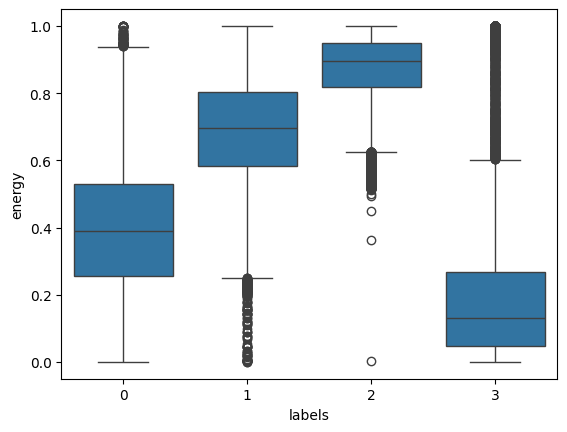

In [28]:
sns.boxplot(data=df, x="labels", y="energy")
plt.show()

**Label 2 (energetic)**  
Har klart högst energy.  
Median runt: 0.9  
- energetic-låtar är konsekvent hög-energy  
- modellen kommer troligen lätt kunna identifiera dem

**Label 3 (calm)**  
Väldigt låg energy.  
Median runt: 0.12  
- vissa calm-låtar har ganska hög energy
- emotions överlappar ibland

**Label 1 (happy)**  
Ligger ganska högt: ~0.7  
Men med större spridning än energetic.  
- happy-musik är mer varierad
- vissa happy-låtar är lugna
- vissa är väldigt energiska

**Label 0 (sad)**  
Mellanläge.  
Det här är väldigt intressant faktiskt.  
Det visar: sad ≠ bara låg energi

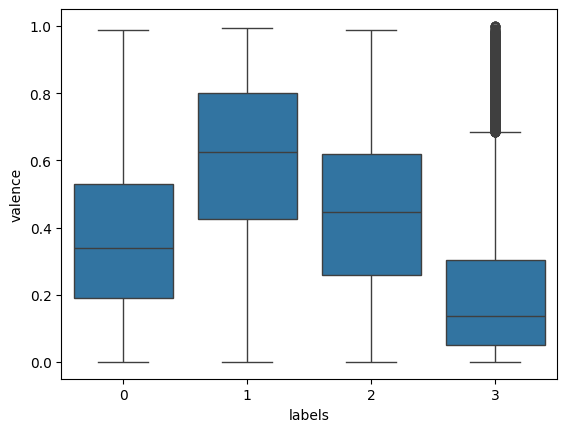

In [29]:
sns.boxplot(data=df, x="labels", y="valence")
plt.show()

**Observation:**  
"valence" verkar vara den mest emotionellt “rena” featuren hittills.  
Den separerar emotions ganska tydligt.

**Happy (1)**  
Har högst valence.  
Median runt: 0.62  
Det passar perfekt med teorin:  
- positiv känsla
- glad musik
- mer “uplifting”  
-Stärker att:  
valence ≈ emotionell positivitet

**Calm (3)** 
Har lägst valence.
Calm verkar vara:
- lågintensiv
- låg emotional positivity
- ambient/meditativ
-Viktig psykologisk observation.

**Energetic (2)**  
Ligger ungefär i mitten.  
SUPERviktigt.  
Det betyder:  
- energetic ≠ happy
- hög energi betyder inte positiv emotion  
-Stark insikt för framtida presentationen.

**Sad (0)**  
Lägre valence än energetic och happy, men inte lika extremt låg som calm.  
Det antyder:  
- “sad” musik fortfarande kan innehålla emotionell intensitet
- kanske dramatisk/pop-ballad/trap/etc
---

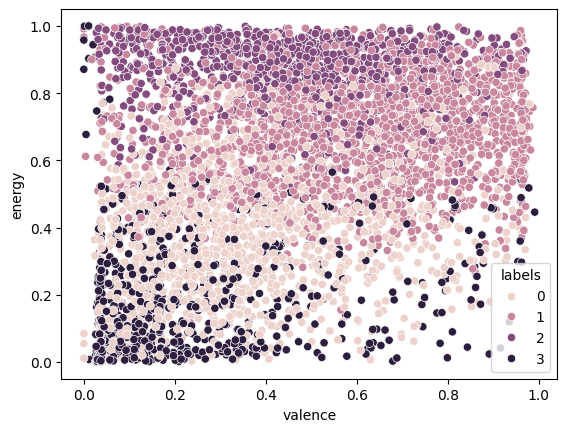

In [30]:
sns.scatterplot(
    data=df.sample(5000),
    x="valence",
    y="energy",
    hue="labels"
)

plt.show()

**Observation:**  
Klasserna är inte perfekt separerade  
Vilket är bra.  
Om allt låg i perfekta grupper hade problemet varit för enkelt.

**Vad grafen visar**
- Varje punkt: = en låt  
- X-axel: valence  
- Y-axel: energy  
- Färg: = emotion label
  
**Calm (3)**  
Det viktigaste vi ser.  
Ligger mest:
- nere till vänster
- låg energy
- låg valence  
Väldigt tydligt område.  
Det betyder: calm verkar lätt att identifiera.

**Energetic (2)**  
Ligger främst:
- högt upp
- hög energy  
Men spridd i valence.  
Matchar exakt vår tidigare hypotes:  
energetic betyder intensivitet, inte nödvändigtvis positiv känsla.

**Happy (1)**  
Tenderar att ligga:
- mer åt höger
- ganska högt upp  
Alltså:
- högre valence
- högre energy

**Sad (0)**  
Mest utspridd.  
Väldigt intressant.  
Det antyder:
- “sad” musik är svårast att definiera
- kanske överlappar med calm
- kanske överlappar med energetic emotionellt  
Det här kan senare bli:
- den svåraste klassen för modellen
- flest felklassificeringar

Vi spara den tanken.

**Viktig ML-insikt**  
Nu har vi börjat se:  

feature space

Det betyder:  
    varje låt är en punkt i ett matematiskt rum av features.

ML-modellen försöker hitta:  
- mönster
- gränser
- områden

för olika emotions.

---

### Korrelationsanalys:

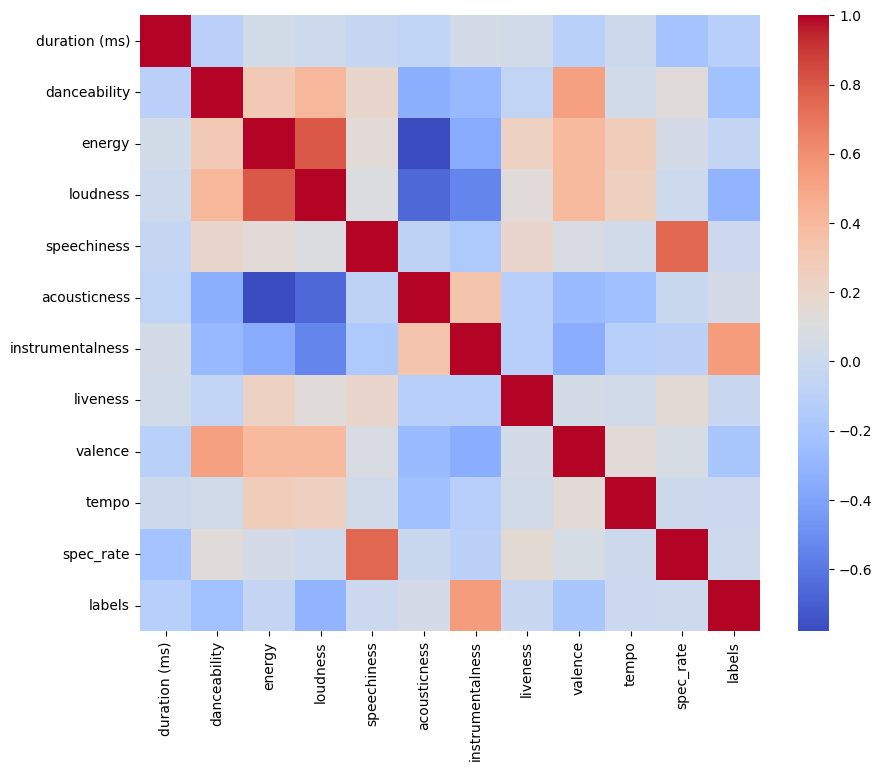

In [31]:
corr = df.drop(columns=["Unnamed: 0"]).corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()